In [1]:
import sqlite3
import pandas as pd


In [2]:
from google.colab import files
import pandas as pd
import sqlite3

# Files upload karo
uploaded = files.upload()

Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_customers_dataset.csv to olist_customers_dataset.csv


In [3]:
import pandas as pd
import sqlite3

# Connection banao
conn = sqlite3.connect(':memory:')

# Saari files load karo aur SQL tables banao
tables = {
    'orders': 'olist_orders_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

for table_name, file_name in tables.items():
    df_temp = pd.read_csv(file_name)
    df_temp.to_sql(table_name, conn, index=False, if_exists='replace')
    print(f"{table_name}: {df_temp.shape}")

orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
products: (32951, 9)
sellers: (3095, 4)
payments: (103886, 5)
reviews: (99224, 7)
category_translation: (71, 2)


In [4]:
query1 = """
SELECT
  order_status,
  COUNT(*) AS total_orders,
  ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS percentage
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

  order_status  total_orders  percentage
0    delivered         96478       97.02
1      shipped          1107        1.11
2     canceled           625        0.63
3  unavailable           609        0.61
4     invoiced           314        0.32
5   processing           301        0.30
6      created             5        0.01
7     approved             2        0.00


In [5]:
query2 = """
SELECT
  ct.product_category_name_english AS category,
  COUNT(DISTINCT oi.order_id) AS total_orders,
  ROUND(SUM(oi.price), 2) AS total_revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY ct.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 10
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

                category  total_orders  total_revenue
0          health_beauty          8836     1258681.34
1          watches_gifts          5624     1205005.68
2         bed_bath_table          9417     1036988.68
3         sports_leisure          7720      988048.97
4  computers_accessories          6689      911954.32
5        furniture_decor          6449      729762.49
6             cool_stuff          3632      635290.85
7             housewares          5884      632248.66
8                   auto          3897      592720.11
9           garden_tools          3518      485256.46


In [6]:
query3 = """
SELECT
  payment_type,
  COUNT(*) AS total_payments,
  ROUND(AVG(payment_value), 2) AS avg_payment_value,
  ROUND(SUM(payment_value), 2) AS total_revenue
FROM payments
GROUP BY payment_type
ORDER BY total_revenue DESC
"""

result3 = pd.read_sql_query(query3, conn)
print(result3)

  payment_type  total_payments  avg_payment_value  total_revenue
0  credit_card           76795             163.32    12542084.19
1       boleto           19784             145.03     2869361.27
2      voucher            5775              65.70      379436.87
3   debit_card            1529             142.57      217989.79
4  not_defined               3               0.00           0.00


In [7]:
query4 = """
SELECT
  CASE
    WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 'Late'
    ELSE 'On Time'
  END AS delivery_status,
  COUNT(*) AS total_orders,
  ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders WHERE order_delivered_customer_date IS NOT NULL), 2) AS percentage
FROM orders
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status
"""

result4 = pd.read_sql_query(query4, conn)
print(result4)

  delivery_status  total_orders  percentage
0            Late          7827        8.11
1         On Time         88649       91.89


In [8]:
query5 = """
SELECT
  CASE
    WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 'Late'
    ELSE 'On Time'
  END AS delivery_status,
  ROUND(AVG(r.review_score), 2) AS avg_review_score,
  COUNT(*) AS total_orders
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status
"""

result5 = pd.read_sql_query(query5, conn)
print(result5)

  delivery_status  avg_review_score  total_orders
0            Late              2.57          7701
1         On Time              4.29         88658


In [9]:
query6 = """
SELECT
  c.customer_state,
  COUNT(DISTINCT o.order_id) AS total_orders,
  ROUND(SUM(oi.price), 2) AS total_revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10
"""

result6 = pd.read_sql_query(query6, conn)
print(result6)

  customer_state  total_orders  total_revenue
0             SP         41375     5202955.05
1             RJ         12762     1824092.67
2             MG         11544     1585308.03
3             RS          5432      750304.02
4             PR          4998      683083.76
5             SC          3612      520553.34
6             BA          3358      511349.99
7             DF          2125      302603.94
8             GO          2007      294591.95
9             ES          2025      275037.31


In [10]:
query7 = """
SELECT
  c.customer_state,
  COUNT(*) AS total_orders,
  ROUND(SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_delivery_pct
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY total_orders DESC
LIMIT 10
"""

result7 = pd.read_sql_query(query7, conn)
print(result7)

  customer_state  total_orders  late_delivery_pct
0             SP         40495               5.89
1             RJ         12353              13.47
2             MG         11355               5.62
3             RS          5344               7.15
4             PR          4923               5.00
5             SC          3547               9.75
6             BA          3256              14.04
7             DF          2080               7.07
8             ES          1995              12.23
9             GO          1957               8.18


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

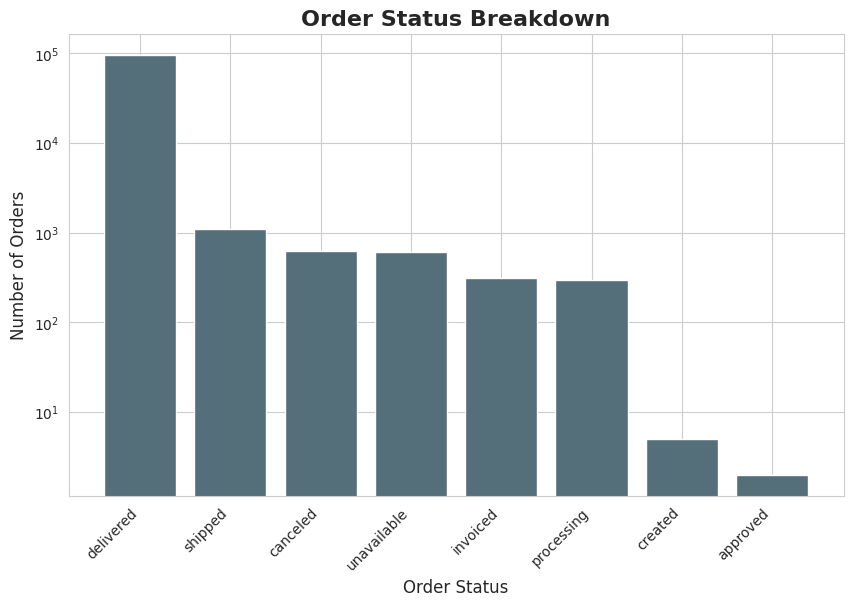

In [12]:
plt.figure(figsize=(10, 6))

status_counts = df_orders['order_status'].value_counts() if 'df_orders' in dir() else pd.read_sql_query("SELECT order_status, COUNT(*) as count FROM orders GROUP BY order_status ORDER BY count DESC", conn)

status_data = pd.read_sql_query("""
SELECT order_status, COUNT(*) as count
FROM orders
GROUP BY order_status
ORDER BY count DESC
""", conn)

plt.bar(status_data['order_status'], status_data['count'], color='#546E7A', edgecolor='white')
plt.title('Order Status Breakdown', fontsize=16, fontweight='bold')
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.savefig('eco_plot1_order_status.png', dpi=150, bbox_inches='tight')
plt.show()

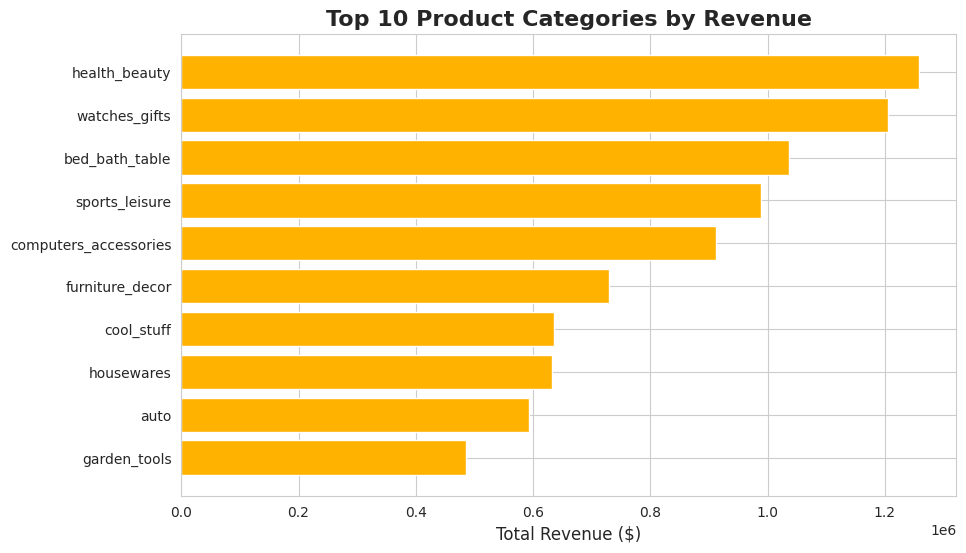

In [13]:
plt.figure(figsize=(10, 6))

category_data = pd.read_sql_query("""
SELECT
  ct.product_category_name_english AS category,
  ROUND(SUM(oi.price), 2) AS total_revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY ct.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 10
""", conn)

plt.barh(category_data['category'], category_data['total_revenue'], color='#FFB300', edgecolor='white')
plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.gca().invert_yaxis()
plt.savefig('eco_plot2_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

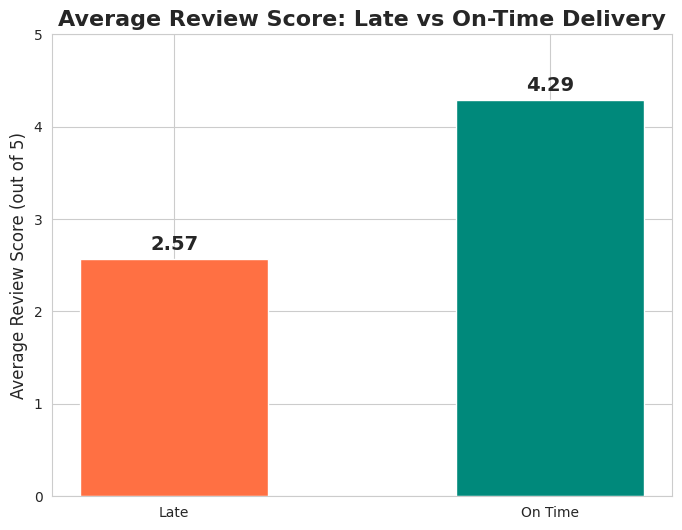

In [14]:
plt.figure(figsize=(8, 6))

delivery_review = pd.read_sql_query("""
SELECT
  CASE
    WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 'Late'
    ELSE 'On Time'
  END AS delivery_status,
  ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status
""", conn)

plt.bar(delivery_review['delivery_status'], delivery_review['avg_review_score'],
        color=['#FF7043', '#00897B'], edgecolor='white', width=0.5)
plt.title('Average Review Score: Late vs On-Time Delivery', fontsize=16, fontweight='bold')
plt.ylabel('Average Review Score (out of 5)', fontsize=12)
plt.ylim(0, 5)

for i, v in enumerate(delivery_review['avg_review_score']):
    plt.text(i, v + 0.1, str(v), ha='center', fontsize=14, fontweight='bold')

plt.savefig('eco_plot3_late_delivery_review.png', dpi=150, bbox_inches='tight')
plt.show()

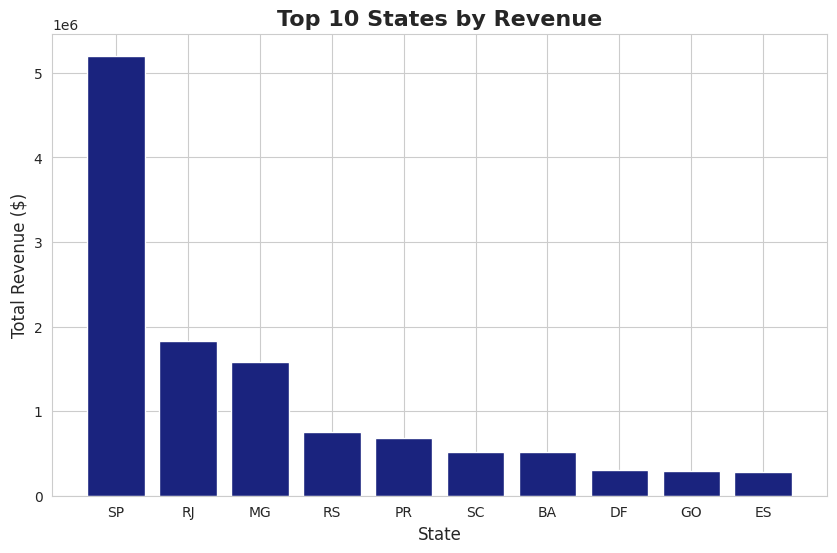

In [15]:
plt.figure(figsize=(10, 6))

state_data = pd.read_sql_query("""
SELECT
  c.customer_state,
  ROUND(SUM(oi.price), 2) AS total_revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10
""", conn)

plt.bar(state_data['customer_state'], state_data['total_revenue'], color='#1A237E', edgecolor='white')
plt.title('Top 10 States by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.savefig('eco_plot4_revenue_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

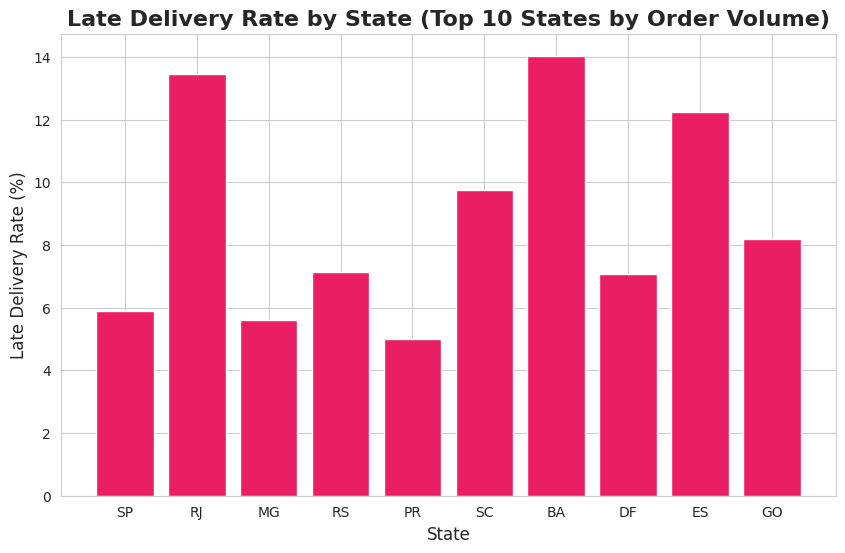

In [16]:
plt.figure(figsize=(10, 6))

late_by_state = pd.read_sql_query("""
SELECT
  c.customer_state,
  COUNT(*) AS total_orders,
  ROUND(SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_delivery_pct
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY total_orders DESC
LIMIT 10
""", conn)

plt.bar(late_by_state['customer_state'], late_by_state['late_delivery_pct'], color='#E91E63', edgecolor='white')
plt.title('Late Delivery Rate by State (Top 10 States by Order Volume)', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Late Delivery Rate (%)', fontsize=12)
plt.savefig('eco_plot5_late_delivery_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from google.colab import files

plots = ['eco_plot1_order_status.png', 'eco_plot2_top_categories.png',
         'eco_plot3_late_delivery_review.png', 'eco_plot4_revenue_by_state.png',
         'eco_plot5_late_delivery_by_state.png']

for plot in plots:
    files.download(plot)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
query8 = """
SELECT
  c.customer_state,
  ct.product_category_name_english AS category,
  COUNT(*) AS total_orders,
  ROUND(SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_delivery_pct
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
WHERE o.order_delivered_customer_date IS NOT NULL
  AND c.customer_state = 'SP'
  AND ct.product_category_name_english = 'health_beauty'
GROUP BY c.customer_state, category
"""

result8 = pd.read_sql_query(query8, conn)
print(result8)

  customer_state       category  total_orders  late_delivery_pct
0             SP  health_beauty          4126               7.76
